In [1]:
import os
import numpy as np
import random
import collections
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # keep deterministic behavior where possible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)


DATA_DIR = '/content/drive/MyDrive/Asg2/processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

BATCH_SIZE = 128
EPOCHS = 40
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


In [4]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [5]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from /content/drive/MyDrive/Asg2/processed_data/quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


In [6]:
data_iter = iter(train_loader)
batch = next(data_iter)

# A batch usually consists of features (images) and labels
# The structure depends on how your Dataset.__getitem__ is implemented
if isinstance(batch, list) or isinstance(batch, tuple):
    images, labels = batch
    print(f"Images shape: {images.shape}")
    print(f"Labels shape: {labels.shape}")
else:
    # If your dataloader returns a single item
    print(f"Batch shape: {batch.shape}")




Images shape: torch.Size([128, 784])
Labels shape: torch.Size([128])


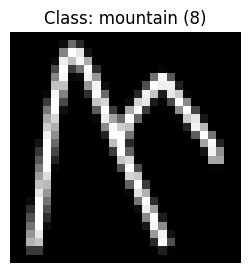

In [7]:
idx = min(60, len(images) - 1)

img = images[idx].numpy().reshape(28, 28)
if img.max() <= 1.0:
    img = img * 255.0
img = img.astype(np.uint8)

class_id = labels[idx].item()
class_names = list(full_train_dataset.classes) if hasattr(full_train_dataset, "classes") else CLASSES
class_name = class_names[class_id]

pil_img = Image.fromarray(img)

plt.figure(figsize=(3, 3))
plt.imshow(pil_img, cmap='gray')
plt.title(f"Class: {class_name} ({class_id})")
plt.axis('off')
plt.show()

In [8]:
DATA_MEAN = full_train_dataset.x.mean().item()
DATA_STD = full_train_dataset.x.std().item() + 1e-8

def normalize_batch(images):
    return (images.float() - DATA_MEAN) / DATA_STD

print(f"DATA_MEAN={DATA_MEAN:.6f}, DATA_STD={DATA_STD:.6f}")

DATA_MEAN=0.188342, DATA_STD=0.338611


In [9]:
def train_one_epoch(model, train_loader, optimizer, criterion, device, scheduler=None):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    grad_sums = collections.defaultdict(float)
    grad_counts = collections.defaultdict(int)
    is_onecycle = isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR)

    for images, labels in train_loader:
        images = normalize_batch(images).to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        for name, parameter in model.named_parameters():
            if parameter.grad is not None and parameter.requires_grad:
                grad_norm = parameter.grad.detach().norm(2).item()
                grad_sums[name] += grad_norm
                grad_counts[name] += 1

        optimizer.step()
        if is_onecycle:
            scheduler.step()

        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += labels.size(0)

    avg_grad_norms = {k: grad_sums[k] / max(1, grad_counts[k]) for k in grad_sums}
    return total_loss / total_samples, total_correct / total_samples, avg_grad_norms


def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = normalize_batch(images).to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * labels.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples


def fit_model(model, model_name, train_loader, val_loader, optimizer, criterion,
              device, scheduler=None, epochs=EPOCHS, verbose=True, save_best_path=None):
    history = {
        "model_name": model_name,
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": [],
        "grad_norms": []
    }

    best_val_acc = -1.0
    best_epoch = -1

    is_onecycle = isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR)
    is_plateau = isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau)

    for epoch in range(1, epochs + 1):
        train_loss, train_acc, grad_norms = train_one_epoch(
            model, train_loader, optimizer, criterion, device, scheduler=scheduler
        )
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        if scheduler is not None:
            if is_plateau:
                scheduler.step(val_acc)
            elif not is_onecycle:
                scheduler.step()

        lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(lr)
        history["grad_norms"].append(grad_norms)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            if save_best_path is not None:
                torch.save(model.state_dict(), save_best_path)

        if verbose:
            print(
                f"[{model_name}] Epoch {epoch:02d}/{epochs} | "
                f"Train: loss {train_loss:.4f}, acc {train_acc:.4f} | "
                f"Val: loss {val_loss:.4f}, acc {val_acc:.4f} | "
                f"LR: {lr:.6f} | Best Val: {best_val_acc:.4f} (ep {best_epoch})"
            )

    history["best_val_acc"] = best_val_acc
    history["best_epoch"] = best_epoch
    if save_best_path is not None:
        print(f"Best checkpoint saved: {save_best_path}")

    return history

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def plot_training_diagnostics(history, top_k_layers=10):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss vs Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs, history["val_acc"], label="Val Acc")
    axes[1].set_title("Accuracy vs Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs, history["lr"], label="Learning Rate")
    axes[2].set_title("Learning Rate vs Epoch")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("LR")
    axes[2].set_yscale("log")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    grad_norms = history.get("grad_norms", [])
    if not grad_norms:
        return

    layer_names = sorted({name for epoch_dict in grad_norms for name in epoch_dict.keys()})
    mean_grad = {}
    for name in layer_names:
        values = [epoch_dict.get(name, np.nan) for epoch_dict in grad_norms]
        values = [v for v in values if not np.isnan(v)]
        mean_grad[name] = np.mean(values) if values else 0.0

    top_layers = sorted(mean_grad, key=mean_grad.get, reverse=True)[:top_k_layers]

    plt.figure(figsize=(12, 6))
    for name in top_layers:
        y = [epoch_dict.get(name, np.nan) for epoch_dict in grad_norms]
        plt.plot(epochs, y, label=name, alpha=0.85)

    plt.title(f"Gradient Norm Traverse (Top {top_k_layers} layers)")
    plt.xlabel("Epoch")
    plt.ylabel("Avg Grad L2 Norm")
    plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def get_predictions_and_labels(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = normalize_batch(images).to(device)
        labels = labels.to(device)

        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    return np.concatenate(all_preds), np.concatenate(all_labels)


def plot_confusion_and_classwise(preds, labels, classes):
    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
    plt.title("Confusion Matrix (Validation Set)")
    plt.tight_layout()
    plt.show()

    class_acc = cm.diagonal() / np.clip(cm.sum(axis=1), 1, None)
    print("Class-wise accuracy (worst to best):")
    for idx in np.argsort(class_acc):
        print(f"{classes[idx]:15s} : {class_acc[idx]:.3f}")

    return cm, class_acc


@torch.no_grad()
def collect_all_misclassified(model, val_loader, device, max_items=None):
    model.eval()
    misclassified = []

    for batch_idx, (images, labels) in enumerate(val_loader):
        logits = model(normalize_batch(images).to(device))
        probs = torch.softmax(logits, dim=1).cpu()
        preds = torch.argmax(probs, dim=1)

        labels_cpu = labels.cpu()
        images_cpu = images.cpu()
        wrong_mask = preds != labels_cpu

        wrong_idx = torch.where(wrong_mask)[0].tolist()
        for idx_in_batch in wrong_idx:
            pred = int(preds[idx_in_batch].item())
            true = int(labels_cpu[idx_in_batch].item())
            misclassified.append({
                "batch_idx": batch_idx,
                "sample_idx": idx_in_batch,
                "true": true,
                "pred": pred,
                "conf": float(probs[idx_in_batch, pred].item()),
                "image": images_cpu[idx_in_batch].detach().clone()
            })
            if max_items is not None and len(misclassified) >= max_items:
                return misclassified

    return misclassified


def show_misclassified_for_pair(misclassified, true_class, pred_class, classes, n=8):
    selected = [m for m in misclassified if m["true"] == true_class and m["pred"] == pred_class]
    if not selected:
        print(f"No samples for pair: {classes[true_class]} -> {classes[pred_class]}")
        return

    selected = sorted(selected, key=lambda x: x["conf"], reverse=True)[:n]
    cols = min(4, len(selected))
    rows = int(np.ceil(len(selected) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, item in zip(axes, selected):
        img = item["image"].view(28, 28).numpy()
        ax.imshow(img, cmap="gray")
        ax.set_title(
            f"{classes[item['true']]} -> {classes[item['pred']]}\nconf={item['conf']:.2f}"
        )
        ax.axis("off")

    for ax in axes[len(selected):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def show_top_misclassified_pairs(misclassified, classes, top_k_pairs=5, samples_per_pair=8):
    pair_counts = collections.Counter((m["true"], m["pred"]) for m in misclassified)
    if not pair_counts:
        print("No misclassified samples found.")
        return

    top_pairs = pair_counts.most_common(top_k_pairs)
    print("Top misclassified class pairs:")
    for (true_class, pred_class), count in top_pairs:
        print(f"{classes[true_class]} -> {classes[pred_class]} : {count}")
        show_misclassified_for_pair(
            misclassified,
            true_class=true_class,
            pred_class=pred_class,
            classes=classes,
            n=samples_per_pair
        )


def run_diagnostics(model, history, val_loader, device, classes,
                    top_k_layers=10, top_k_pairs=5, samples_per_pair=8):
    plot_training_diagnostics(history, top_k_layers=top_k_layers)

    preds, labels = get_predictions_and_labels(model, val_loader, device)
    print("Validation accuracy:", float((preds == labels).mean()))

    cm, class_acc = plot_confusion_and_classwise(preds, labels, classes)

    misclassified = collect_all_misclassified(model, val_loader, device)
    print("Total misclassified samples:", len(misclassified))

    show_top_misclassified_pairs(
        misclassified,
        classes=classes,
        top_k_pairs=top_k_pairs,
        samples_per_pair=samples_per_pair
    )

    return {
        "preds": preds,
        "labels": labels,
        "cm": cm,
        "class_acc": class_acc,
        "misclassified": misclassified
    }

In [11]:
import torch.nn.functional as F


class TokenMixBlockNoSkip(nn.Module):
    def __init__(self, num_tokens, d_model, token_mlp_dim, channel_mlp_dim, dropout=0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.token_mlp = nn.Sequential(
            nn.Linear(num_tokens, token_mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(token_mlp_dim, num_tokens),
            nn.Dropout(dropout),
        )

        self.ln2 = nn.LayerNorm(d_model)
        self.channel_mlp = nn.Sequential(
            nn.Linear(d_model, channel_mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(channel_mlp_dim, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = self.ln1(x)
        x = self.token_mlp(x.transpose(1, 2)).transpose(1, 2)

        x = self.ln2(x)
        x = self.channel_mlp(x)
        return x


class TokenMixingMLP(nn.Module):
    def __init__(
        self,
        num_classes=15,
        image_size=28,
        patch_size=2,
        d_model=192,
        depth=3,
        token_mlp_dim=256,
        channel_mlp_dim=256,
        dropout=0.05,
    ):
        super().__init__()
        assert image_size % patch_size == 0, "patch_size must divide image_size"

        self.image_size = image_size
        self.patch_size = patch_size

        patches_per_side = image_size // patch_size
        self.num_tokens = patches_per_side * patches_per_side
        patch_dim = patch_size * patch_size

        self.patch_embed = nn.Linear(patch_dim, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_tokens, d_model))
        nn.init.normal_(self.pos_embed, std=0.02)

        self.blocks = nn.Sequential(*[
            TokenMixBlockNoSkip(
                num_tokens=self.num_tokens,
                d_model=d_model,
                token_mlp_dim=token_mlp_dim,
                channel_mlp_dim=channel_mlp_dim,
                dropout=dropout,
            )
            for _ in range(depth)
        ])

        self.ln_out = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)

        nn.init.xavier_uniform_(self.patch_embed.weight)
        nn.init.zeros_(self.patch_embed.bias)
        nn.init.xavier_uniform_(self.head.weight)
        nn.init.zeros_(self.head.bias)

    def _to_image(self, x):
        if x.dim() == 2:
            return x.view(x.size(0), 1, self.image_size, self.image_size)

        if x.dim() == 3:
            if x.shape[1] == self.image_size and x.shape[2] == self.image_size:
                return x.unsqueeze(1)
            if x.shape[1] == 1 and x.shape[2] == self.image_size * self.image_size:
                return x.view(x.size(0), 1, self.image_size, self.image_size)

        if x.dim() == 4 and x.shape[1] == 1:
            return x

        raise ValueError(f"Unsupported input shape: {tuple(x.shape)}")

    def _to_tokens(self, x):
        patches = F.unfold(x, kernel_size=self.patch_size, stride=self.patch_size)
        return patches.transpose(1, 2)

    def forward(self, x):
        x = self._to_image(x)
        tokens = self._to_tokens(x)

        x = self.patch_embed(tokens)
        x = x + self.pos_embed
        x = self.blocks(x)
        x = self.ln_out(x)
        x = x.mean(dim=1)

        return self.head(x)

In [12]:
tokenmix_config = {
    "patch_size": 2,
    "d_model": 192,
    "depth": 3,
    "token_mlp_dim": 256,
    "channel_mlp_dim": 256,
    "dropout": 0.05,
}

tokenmix_3layer = TokenMixingMLP(
    num_classes=NUM_CLASSES,
    **tokenmix_config,
).to(DEVICE)

print("TokenMixingMLP config:", tokenmix_config)
print("Total parameters:", sum(p.numel() for p in tokenmix_3layer.parameters()))

TokenMixingMLP config: {'patch_size': 2, 'd_model': 192, 'depth': 3, 'token_mlp_dim': 256, 'channel_mlp_dim': 256, 'dropout': 0.05}
Total parameters: 642843


In [13]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.01)

optimizer = torch.optim.AdamW(
    tokenmix_3layer.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
    betas=(0.9, 0.99),
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=4e-3,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.2,
    anneal_strategy="cos",
    div_factor=10,
    final_div_factor=100,
)

tokenmix_hist = fit_model(
    model=tokenmix_3layer,
    model_name="TokenMixingMLP_depth3",
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    device=DEVICE,
    epochs=EPOCHS,
    verbose=True,
    save_best_path="best_tokenmix_3layer.pth",
)

tokenmix_3layer.load_state_dict(torch.load("best_tokenmix_3layer.pth", map_location=DEVICE))
print(f"Best val acc: {tokenmix_hist['best_val_acc']:.4f} at epoch {tokenmix_hist['best_epoch']}")

[TokenMixingMLP_depth3] Epoch 01/40 | Train: loss 1.2829, acc 0.5766 | Val: loss 1.0414, acc 0.6727 | LR: 0.000537 | Best Val: 0.6727 (ep 1)
[TokenMixingMLP_depth3] Epoch 02/40 | Train: loss 0.9765, acc 0.6881 | Val: loss 1.0101, acc 0.6807 | LR: 0.000928 | Best Val: 0.6807 (ep 2)
[TokenMixingMLP_depth3] Epoch 03/40 | Train: loss 0.9125, acc 0.7128 | Val: loss 0.9238, acc 0.7103 | LR: 0.001512 | Best Val: 0.7103 (ep 3)
[TokenMixingMLP_depth3] Epoch 04/40 | Train: loss 0.8604, acc 0.7342 | Val: loss 0.9270, acc 0.7137 | LR: 0.002201 | Best Val: 0.7137 (ep 4)
[TokenMixingMLP_depth3] Epoch 05/40 | Train: loss 0.8153, acc 0.7510 | Val: loss 0.8736, acc 0.7309 | LR: 0.002890 | Best Val: 0.7309 (ep 5)
[TokenMixingMLP_depth3] Epoch 06/40 | Train: loss 0.7730, acc 0.7644 | Val: loss 0.8468, acc 0.7478 | LR: 0.003474 | Best Val: 0.7478 (ep 6)
[TokenMixingMLP_depth3] Epoch 07/40 | Train: loss 0.7212, acc 0.7826 | Val: loss 0.8286, acc 0.7513 | LR: 0.003864 | Best Val: 0.7513 (ep 7)
[TokenMixingM

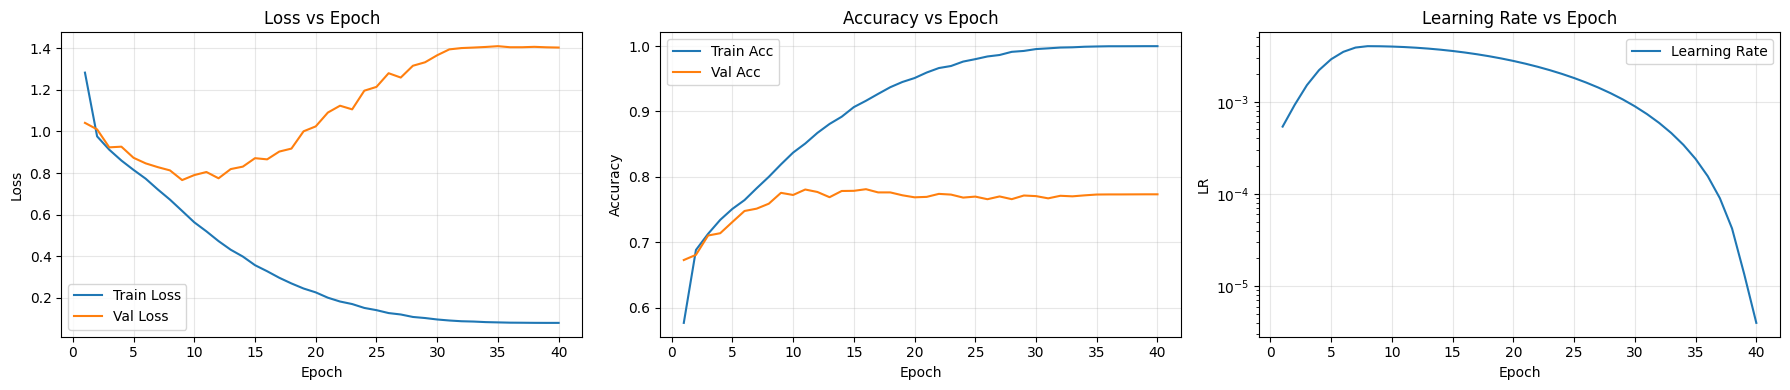

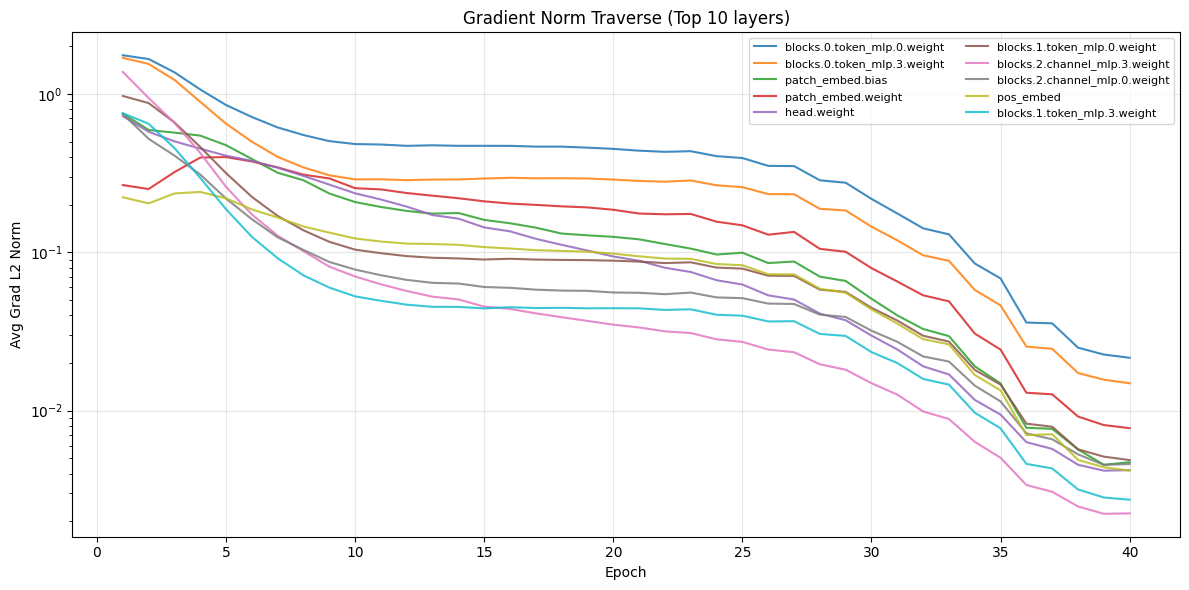

Validation accuracy: 0.7810833333333334


<Figure size 1200x1000 with 0 Axes>

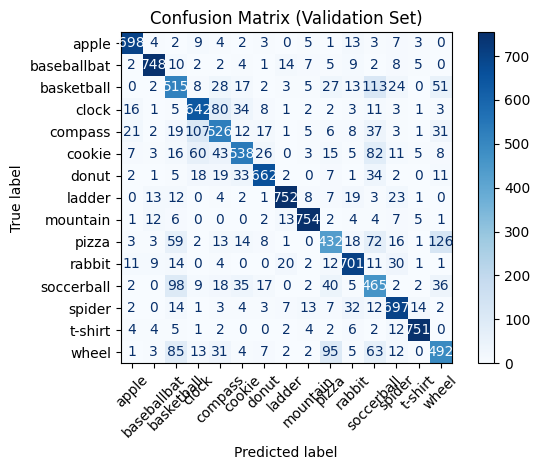

Class-wise accuracy (worst to best):
pizza           : 0.562
wheel           : 0.604
soccerball      : 0.636
basketball      : 0.637
cookie          : 0.655
compass         : 0.661
clock           : 0.791
donut           : 0.831
rabbit          : 0.859
spider          : 0.859
ladder          : 0.890
baseballbat     : 0.913
apple           : 0.926
mountain        : 0.930
t-shirt         : 0.945
Total misclassified samples: 2627
Top misclassified class pairs:
pizza -> wheel : 126


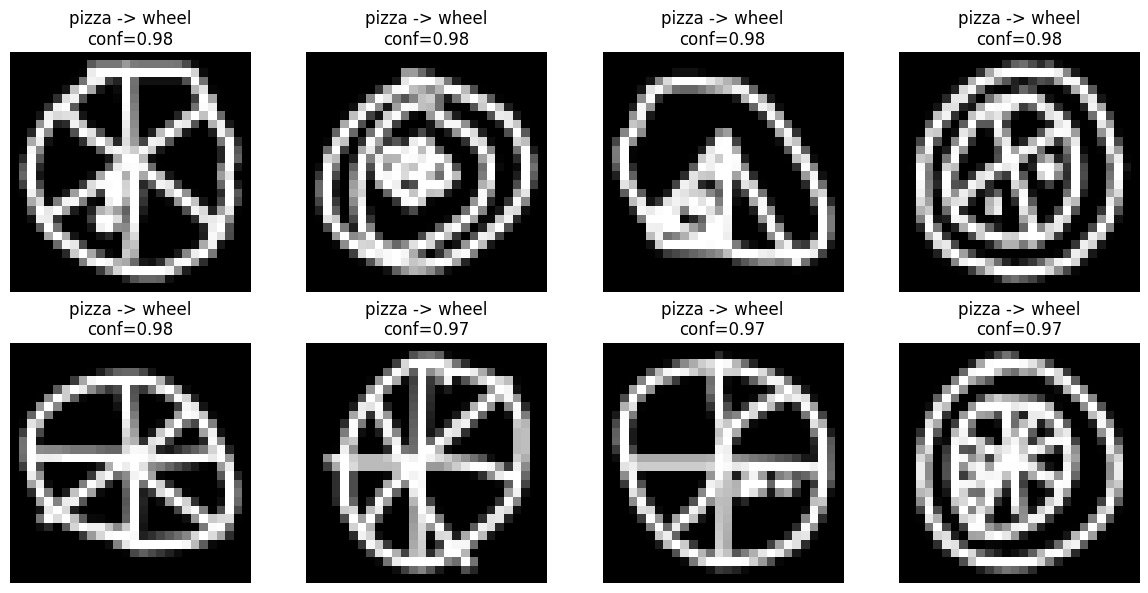

basketball -> soccerball : 113


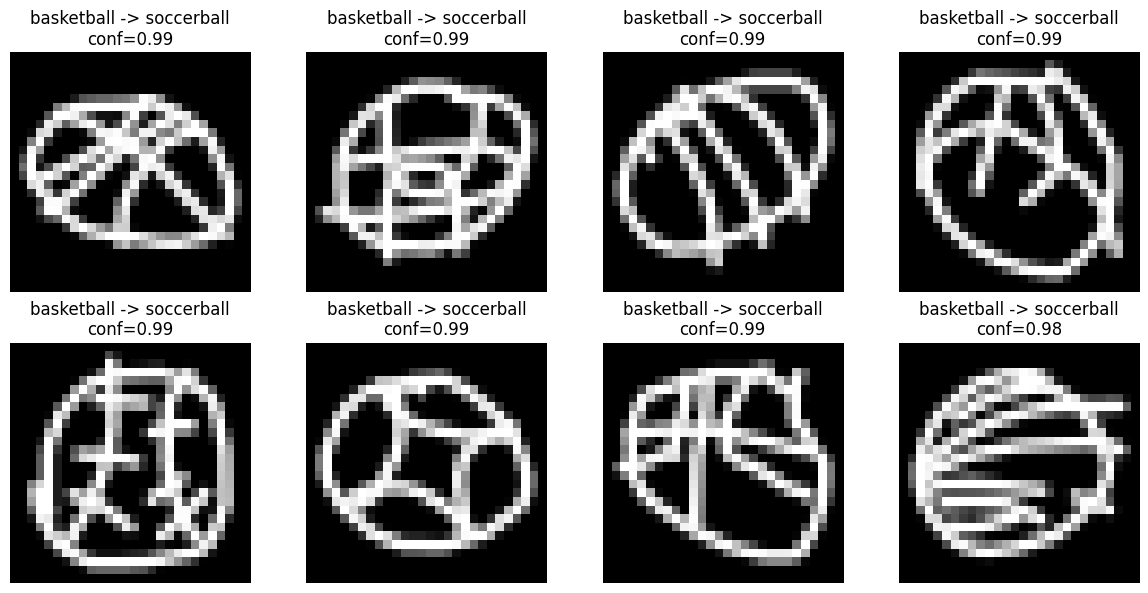

compass -> clock : 107


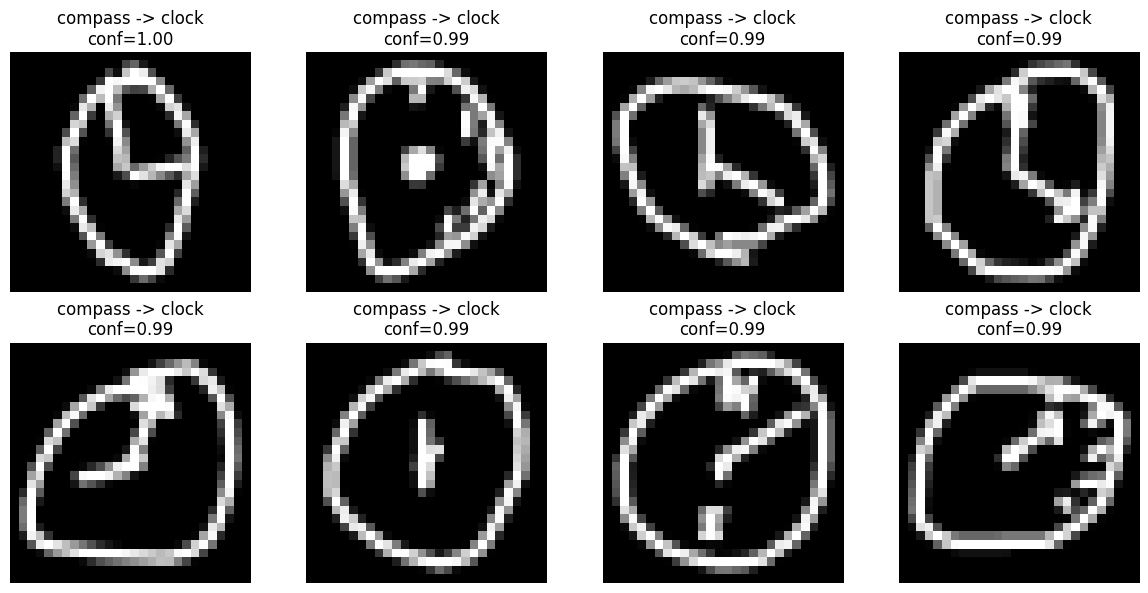

soccerball -> basketball : 98


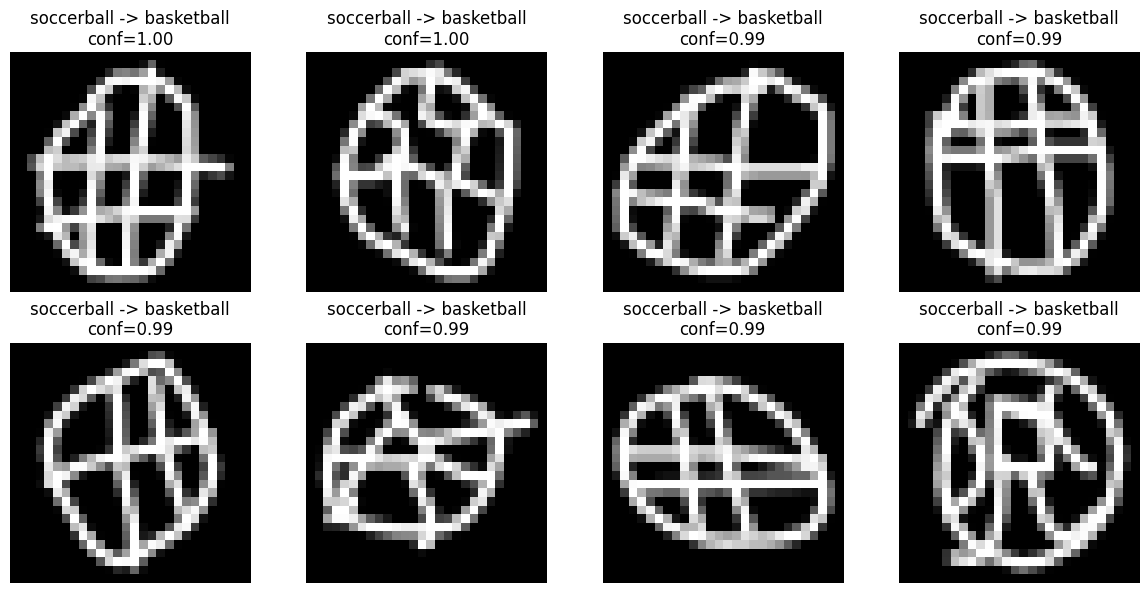

wheel -> pizza : 95


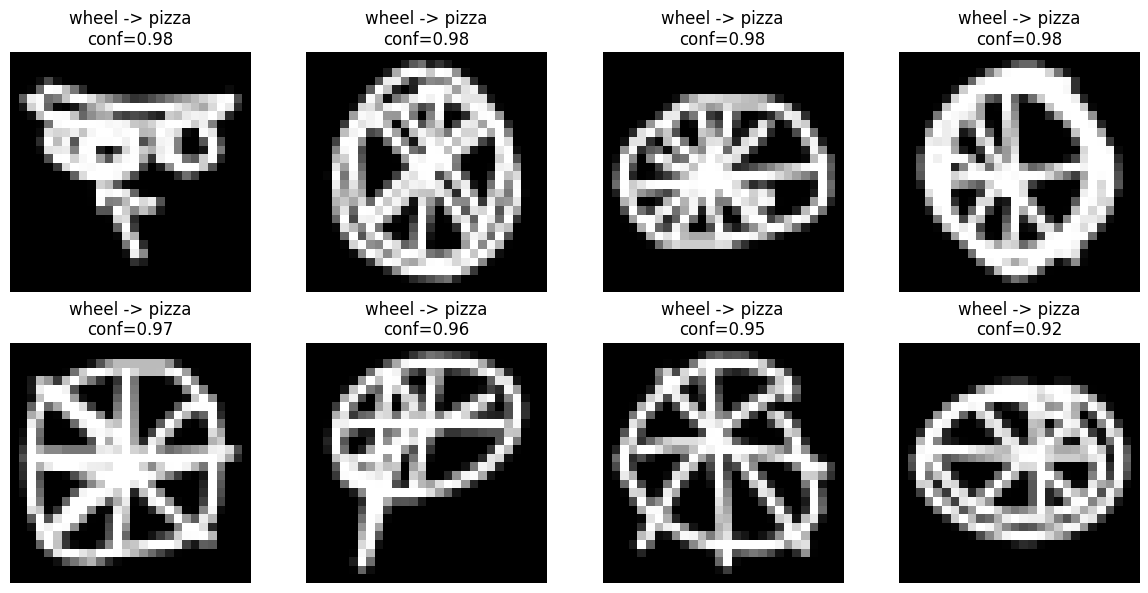

In [14]:
diagnostics = run_diagnostics(
    model=tokenmix_3layer,
    history=tokenmix_hist,
    val_loader=val_loader,
    device=DEVICE,
    classes=CLASSES,
    top_k_layers=10,
    top_k_pairs=5,
    samples_per_pair=8,
)